
## Algerian Forest Fires Dataset

Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012. The dataset includes 11 attribures and 1 output attribue (class) The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.


Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012) Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8 FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

#BASIC CLEANING-


In [ ]:
# EDA-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
#reading the dataset-
df = pd.read_csv('/content/sample_data/Algerian_forest_fires_dataset_UPDATE.csv',header=1)
print(df)

    day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI   BUI  \
0    01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3   3.4   
1    02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1   3.9   
2    03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3   2.7   
3    04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0   1.7   
4    05    06  2012          27  77  16     0  64.8    3  14.2  1.2   3.9   
..   ..   ...   ...         ...  ..  ..   ...   ...  ...   ...  ...   ...   
241  26    09  2012          30  65  14     0  85.4   16  44.5  4.5  16.9   
242  27    09  2012          28  87  15   4.4  41.1  6.5     8  0.1   6.2   
243  28    09  2012          27  87  29   0.5  45.9  3.5   7.9  0.4   3.4   
244  29    09  2012          24  54  18   0.1  79.7  4.3  15.2  1.7   5.1   
245  30    09  2012          24  64  15   0.2  67.3  3.8  16.5  1.2   4.8   

     FWI     Classes    
0    0.5   not fire     
1    0.4   not fire     


In [ ]:
df = df.dropna(how='all')
print(df)

    day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI   BUI  \
0    01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3   3.4   
1    02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1   3.9   
2    03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3   2.7   
3    04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0   1.7   
4    05    06  2012          27  77  16     0  64.8    3  14.2  1.2   3.9   
..   ..   ...   ...         ...  ..  ..   ...   ...  ...   ...  ...   ...   
241  26    09  2012          30  65  14     0  85.4   16  44.5  4.5  16.9   
242  27    09  2012          28  87  15   4.4  41.1  6.5     8  0.1   6.2   
243  28    09  2012          27  87  29   0.5  45.9  3.5   7.9  0.4   3.4   
244  29    09  2012          24  54  18   0.1  79.7  4.3  15.2  1.7   5.1   
245  30    09  2012          24  64  15   0.2  67.3  3.8  16.5  1.2   4.8   

     FWI     Classes    
0    0.5   not fire     
1    0.4   not fire     


In [ ]:
#index containing headers of Siddi Bel Abbes Region
demarcating_index = df.loc[df['day']=='day',:].index[0]
print(demarcating_index)

123


In [ ]:
#encoding for regions,Bejaya = 0 and Siddi Bel Abbes-1
df.loc[0:demarcating_index,'Region']=0
df.loc[demarcating_index:,'Region']=1

In [ ]:
print(df)

    day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI   BUI  \
0    01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3   3.4   
1    02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1   3.9   
2    03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3   2.7   
3    04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0   1.7   
4    05    06  2012          27  77  16     0  64.8    3  14.2  1.2   3.9   
..   ..   ...   ...         ...  ..  ..   ...   ...  ...   ...  ...   ...   
241  26    09  2012          30  65  14     0  85.4   16  44.5  4.5  16.9   
242  27    09  2012          28  87  15   4.4  41.1  6.5     8  0.1   6.2   
243  28    09  2012          27  87  29   0.5  45.9  3.5   7.9  0.4   3.4   
244  29    09  2012          24  54  18   0.1  79.7  4.3  15.2  1.7   5.1   
245  30    09  2012          24  64  15   0.2  67.3  3.8  16.5  1.2   4.8   

     FWI     Classes    Region  
0    0.5   not fire        0.0  
1    0.4 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [ ]:
#Data cleaning-
#found the SIddi Bel Abbes entry-
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [ ]:
#dropping unnecessary rows-
df = df.drop(index=122,axis=0)
print(df[df.isnull().any(axis=1)])

    day month  year Temperature  RH  Ws Rain   FFMC   DMC      DC   ISI   BUI  \
167  14    07  2012          37  37  18   0.2  88.9  12.9  14.6 9  12.5  10.4   

         FWI Classes    Region  
167  fire          NaN     1.0  


In [ ]:
df.loc[df['day']=='day',:].index

Index([123], dtype='int64')

In [ ]:
df = df.drop(index=123)

In [ ]:
# Strip any whitespace from column names
df.columns = df.columns.str.strip()

# Convert numeric columns to float (errors='coerce' handles unexpected strings)
cols_to_fix = ['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric, errors='coerce')

# Convert date components to integers
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws','Region']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws','Region']].astype(int)

In [ ]:
#checking datatypes now-
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       244 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.5+ KB


In [ ]:
#Removing the null entries-
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,1


In [ ]:
df = df.dropna()


     day  month  year  Temperature  RH  Ws  Rain  FFMC   DMC    DC  ISI   BUI  \
0      1      6  2012           29  57  18   0.0  65.7   3.4   7.6  1.3   3.4   
1      2      6  2012           29  61  13   1.3  64.4   4.1   7.6  1.0   3.9   
2      3      6  2012           26  82  22  13.1  47.1   2.5   7.1  0.3   2.7   
3      4      6  2012           25  89  13   2.5  28.6   1.3   6.9  0.0   1.7   
4      5      6  2012           27  77  16   0.0  64.8   3.0  14.2  1.2   3.9   
..   ...    ...   ...          ...  ..  ..   ...   ...   ...   ...  ...   ...   
241   26      9  2012           30  65  14   0.0  85.4  16.0  44.5  4.5  16.9   
242   27      9  2012           28  87  15   4.4  41.1   6.5   8.0  0.1   6.2   
243   28      9  2012           27  87  29   0.5  45.9   3.5   7.9  0.4   3.4   
244   29      9  2012           24  54  18   0.1  79.7   4.3  15.2  1.7   5.1   
245   30      9  2012           24  64  15   0.2  67.3   3.8  16.5  1.2   4.8   

     FWI       Classes  Reg

In [ ]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [ ]:
#resetting proper index values-
df = df.dropna().reset_index(drop=True)
print(df)

     day  month  year  Temperature  RH  Ws  Rain  FFMC   DMC    DC  ISI   BUI  \
0      1      6  2012           29  57  18   0.0  65.7   3.4   7.6  1.3   3.4   
1      2      6  2012           29  61  13   1.3  64.4   4.1   7.6  1.0   3.9   
2      3      6  2012           26  82  22  13.1  47.1   2.5   7.1  0.3   2.7   
3      4      6  2012           25  89  13   2.5  28.6   1.3   6.9  0.0   1.7   
4      5      6  2012           27  77  16   0.0  64.8   3.0  14.2  1.2   3.9   
..   ...    ...   ...          ...  ..  ..   ...   ...   ...   ...  ...   ...   
238   26      9  2012           30  65  14   0.0  85.4  16.0  44.5  4.5  16.9   
239   27      9  2012           28  87  15   4.4  41.1   6.5   8.0  0.1   6.2   
240   28      9  2012           27  87  29   0.5  45.9   3.5   7.9  0.4   3.4   
241   29      9  2012           24  54  18   0.1  79.7   4.3  15.2  1.7   5.1   
242   30      9  2012           24  64  15   0.2  67.3   3.8  16.5  1.2   4.8   

     FWI       Classes  Reg

In [ ]:
df.index

RangeIndex(start=0, stop=243, step=1)

In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
#we need to encode this column into numeric value-
[column for column in df.columns if df[column].dtype == 'object']

['Classes']

In [ ]:
#Statiscal analysis-
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


#FEATURE ENGG AND EDA-


In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df["Classes"] = df["Classes"].str.strip()
print(df["Classes"].unique())

['not fire' 'fire']


In [ ]:
# Label encoding not fire = 0 and fire=1
df['Classes'] = df['Classes'].map({'not fire':0,'fire':1})

In [ ]:
df['Classes'] = df['Classes'].astype(int)

In [ ]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [ ]:
#dropping time series columns
df_viz = df.drop(columns=['day','month','year'],axis=1)

#VISUALIZATION-


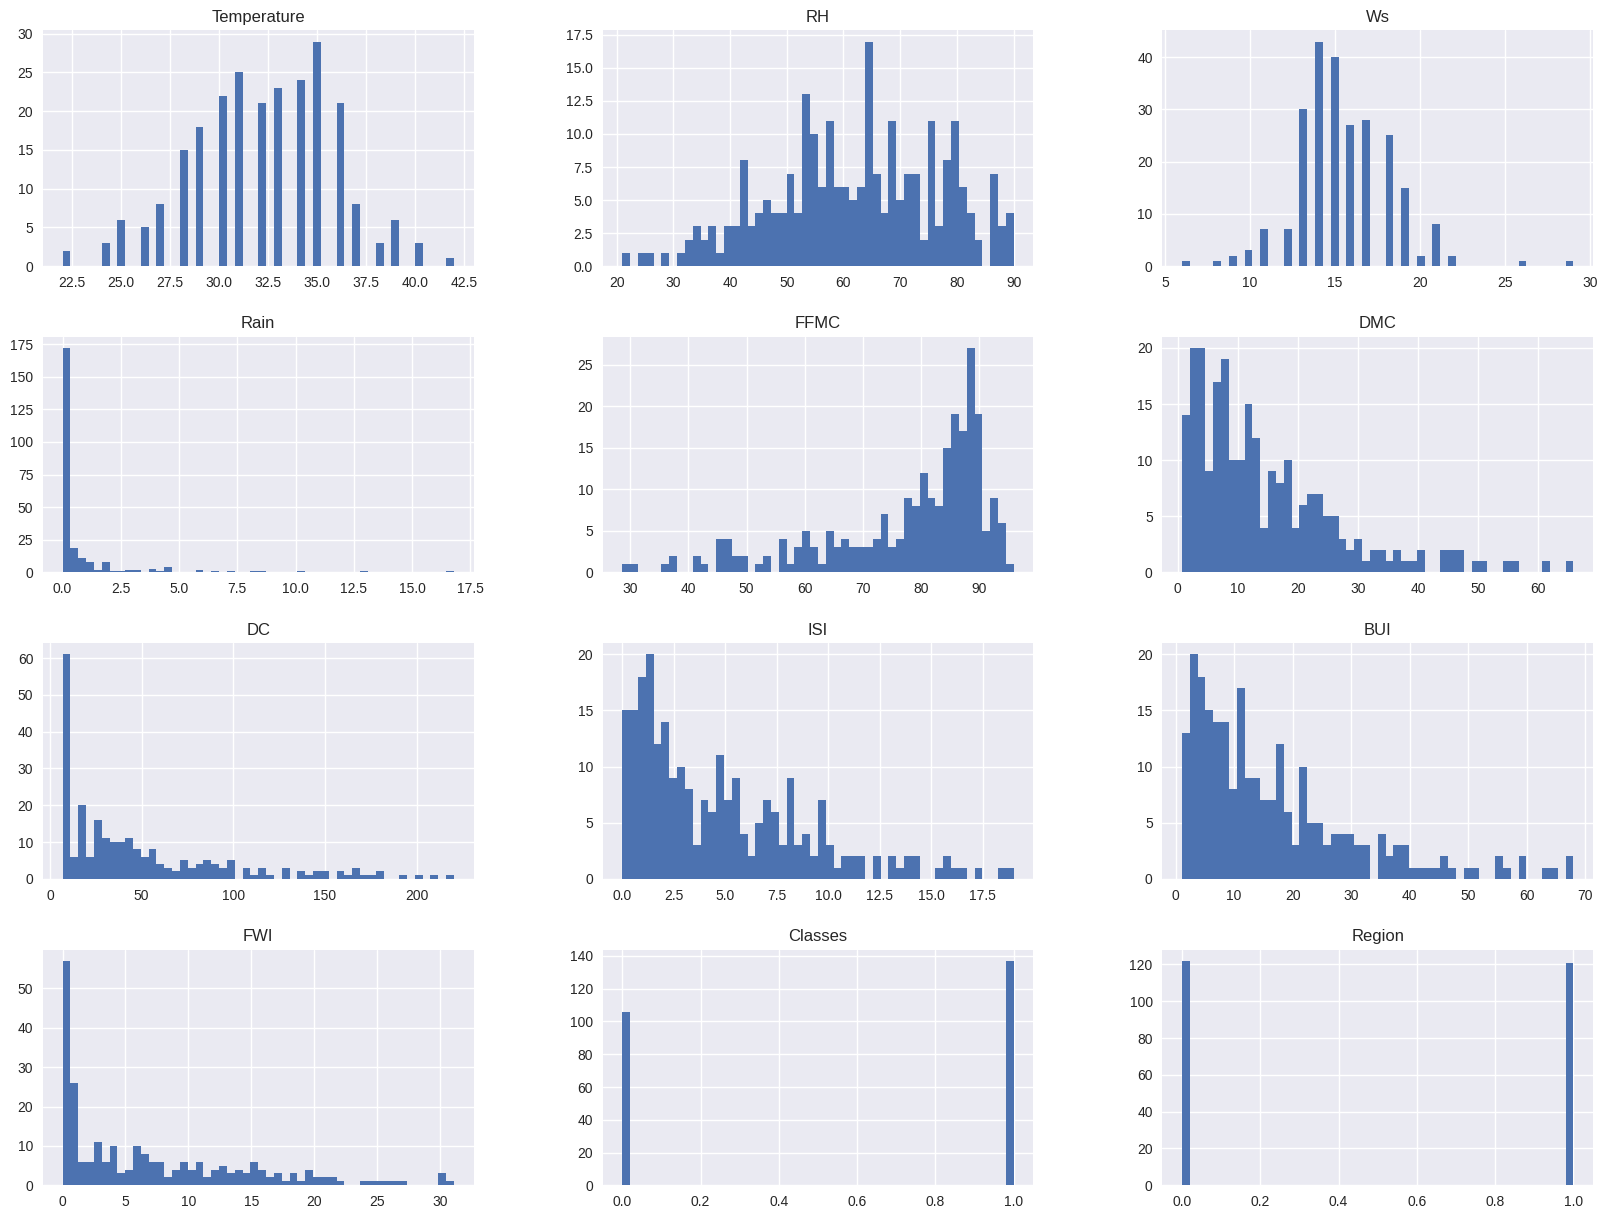

In [ ]:
import matplotlib.pyplot as plt

# Update the style name here
plt.style.use('seaborn-v0_8')

df_viz.hist(bins=50, figsize=(20,15))
plt.show()

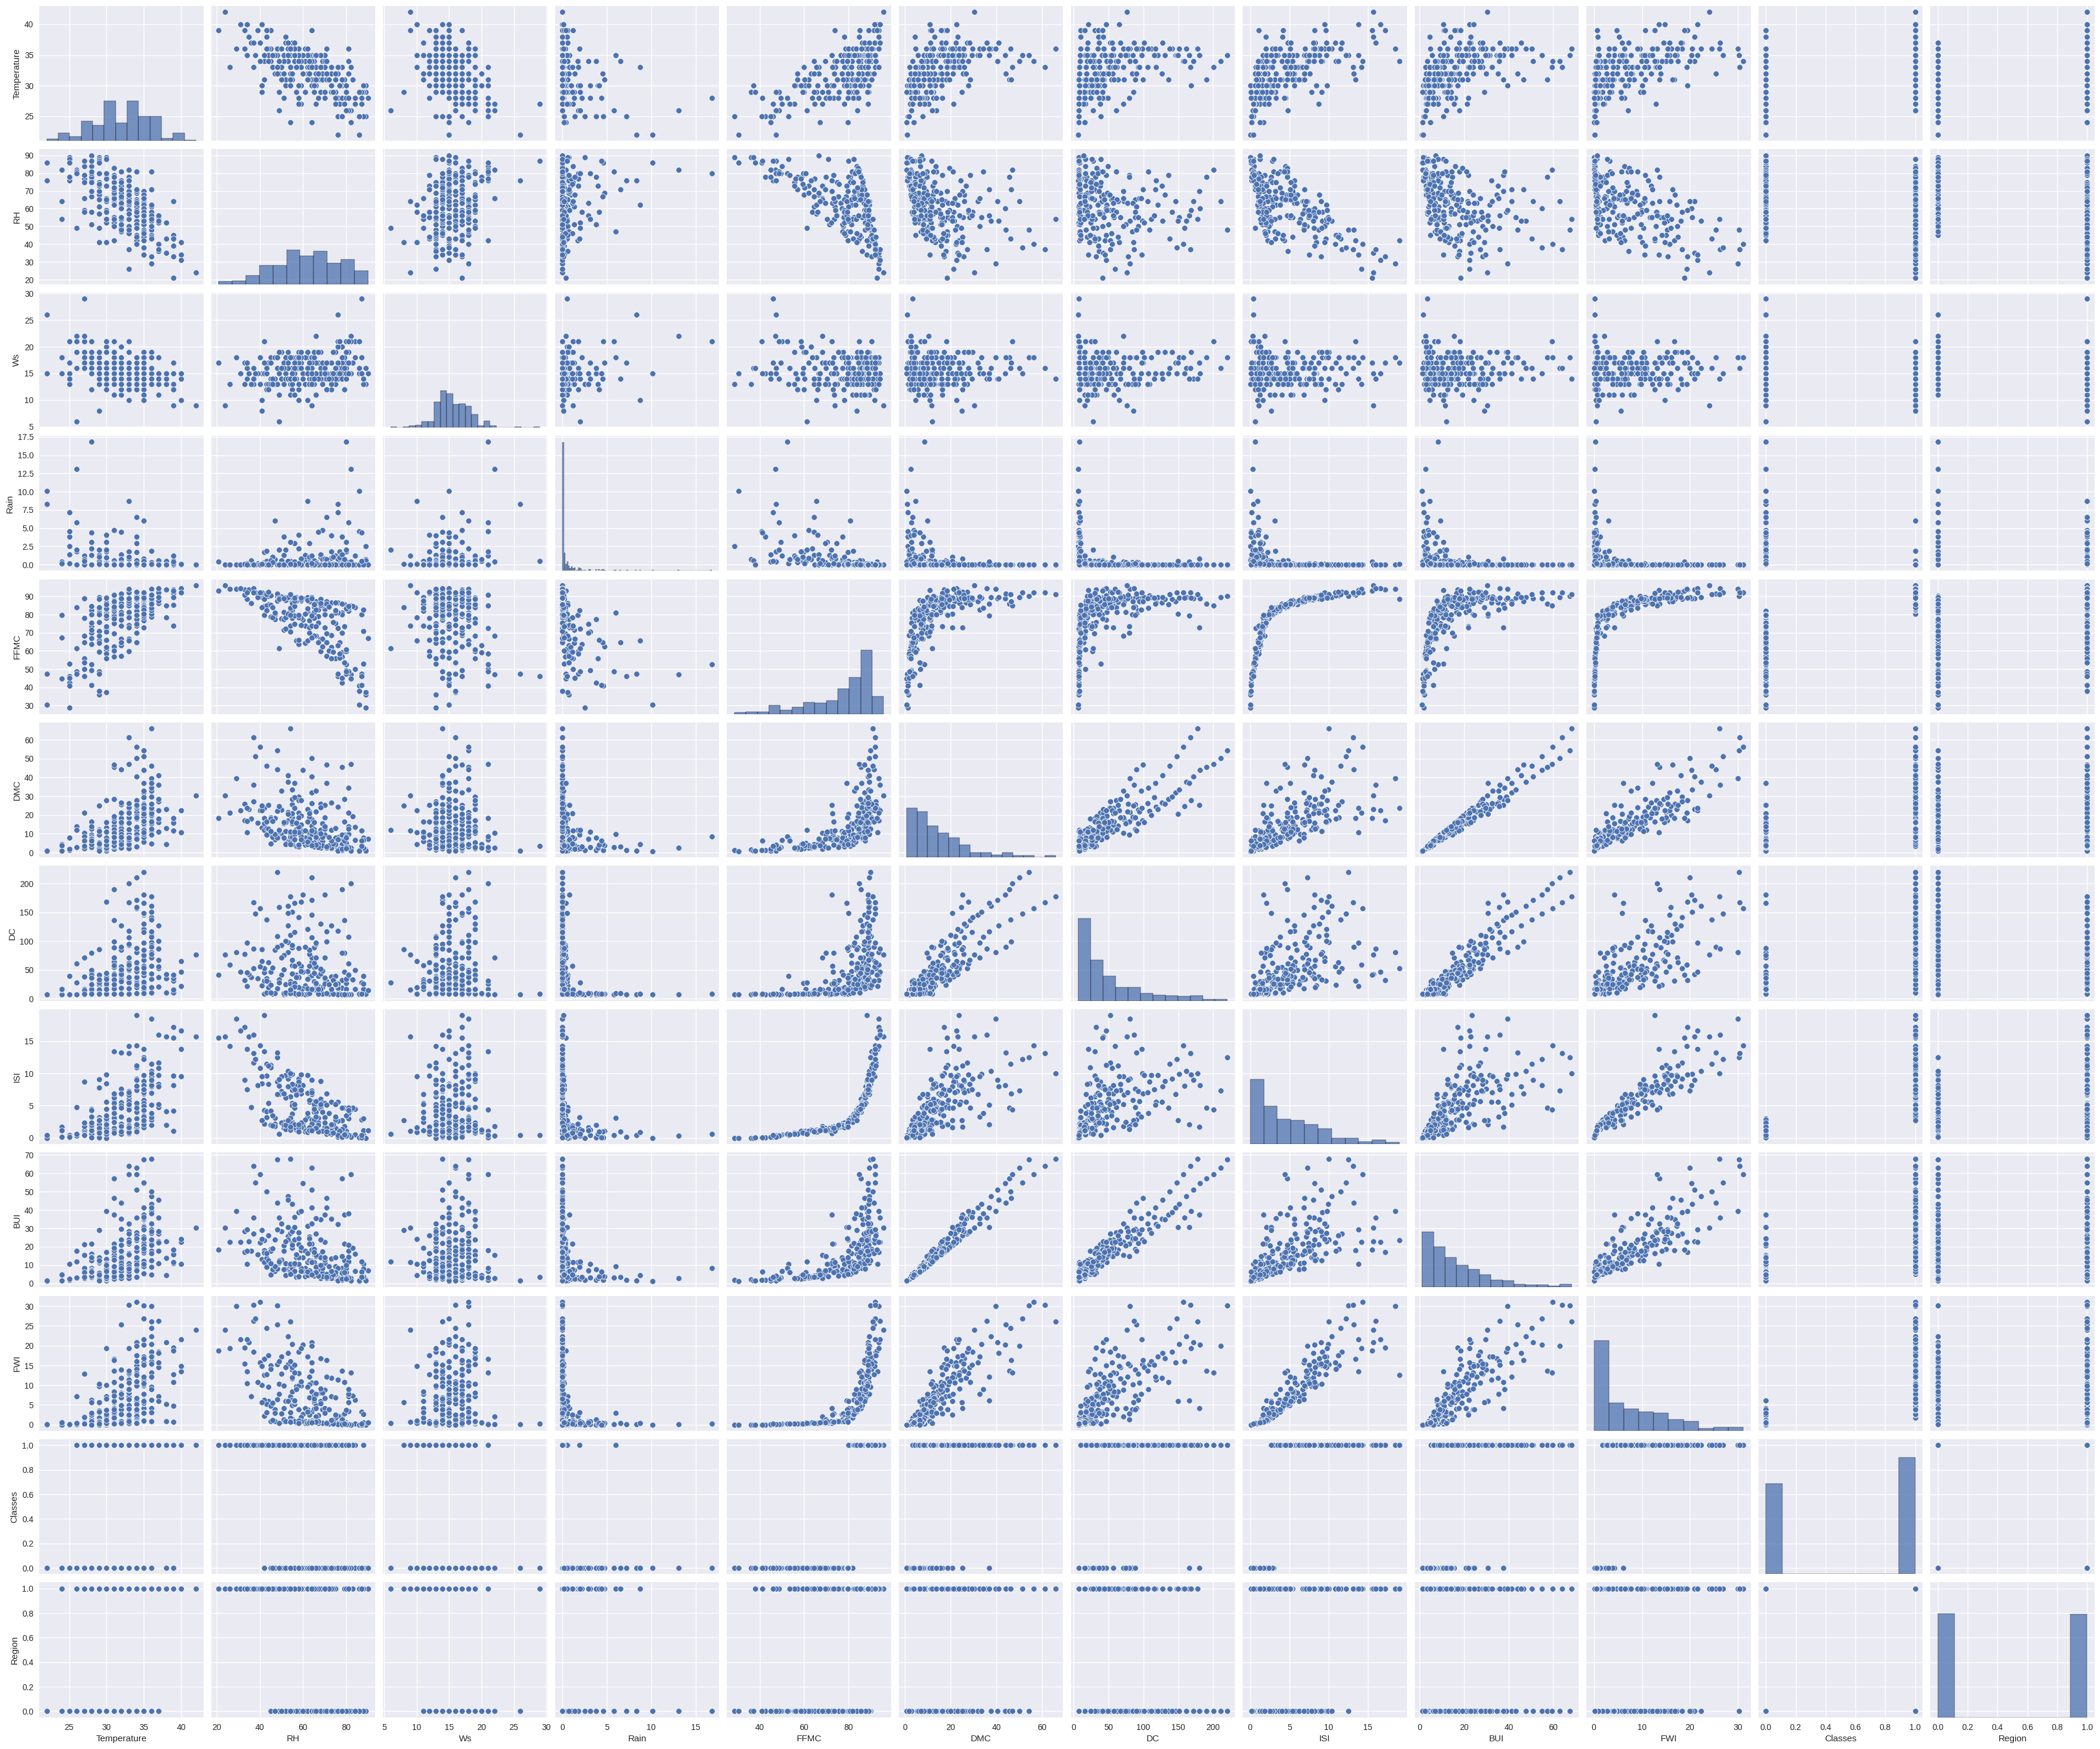

In [ ]:
# 'height' sets the height of each subplot in inches.
# 'aspect' makes the subplots wider (width = height * aspect).
sns.pairplot(df_viz, height=2.5, aspect=1.2)

In [ ]:
# Percentage for Pie Charts-
perce = df_viz['Classes'].value_counts(normalize=True)*100

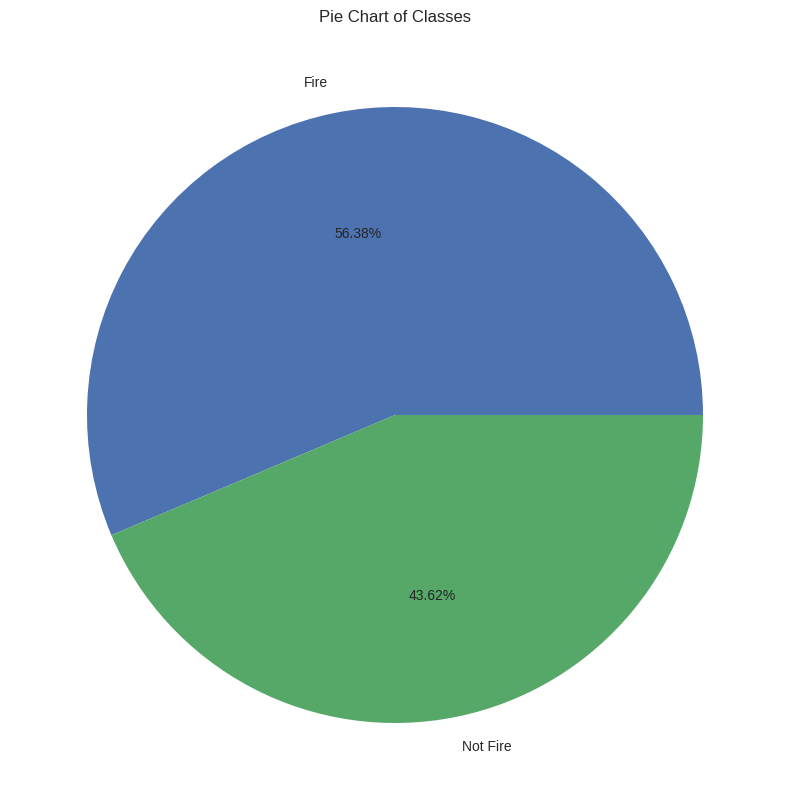

In [ ]:
#PLOTTING PIECHART-
classes = ["Fire","Not Fire"]
plt.figure(figsize=(10,10))
plt.pie(perce,labels=classes,autopct='%1.2f%%')
plt.title("Pie Chart of Classes")
plt.show()

## Checking Correlation and possibility of multicollinearity-
Multicollinearity- If 2 or more independent features are highly correlated,it makes sense to drop one of the features from the model.


In [ ]:
df_viz.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

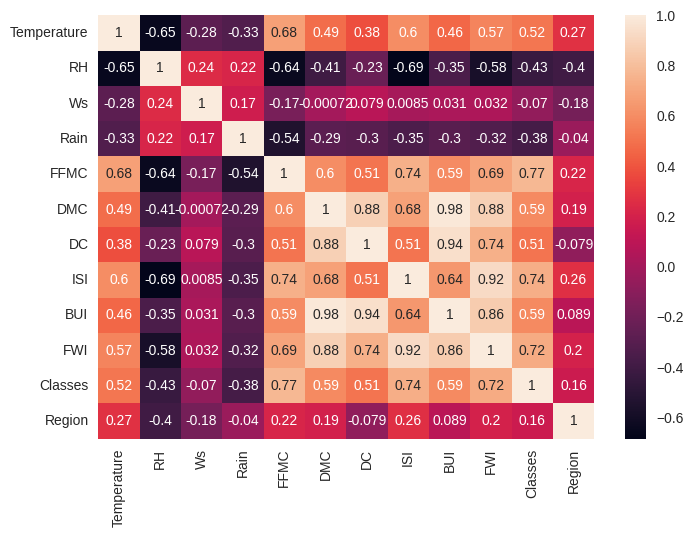

In [ ]:
sns.heatmap(df_viz.corr(),annot=True)

<Axes: ylabel='FWI'>

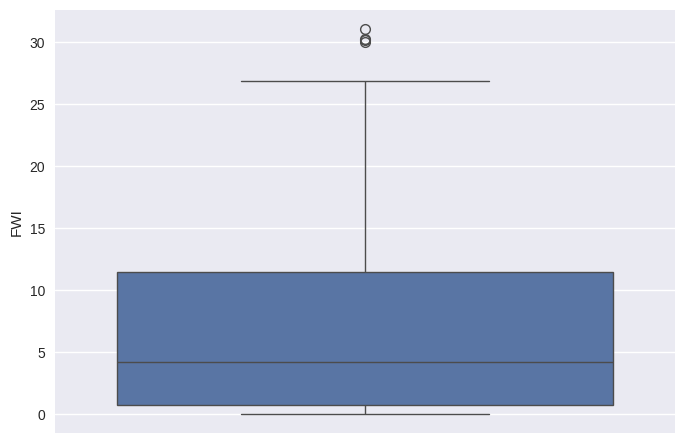

In [ ]:
#BOXPLOT(checking outliers in the dependent variable)-
sns.boxplot(df_viz['FWI'])

Text(0.5, 1.0, 'Monthly Fire Analysis For Bejaya Region')

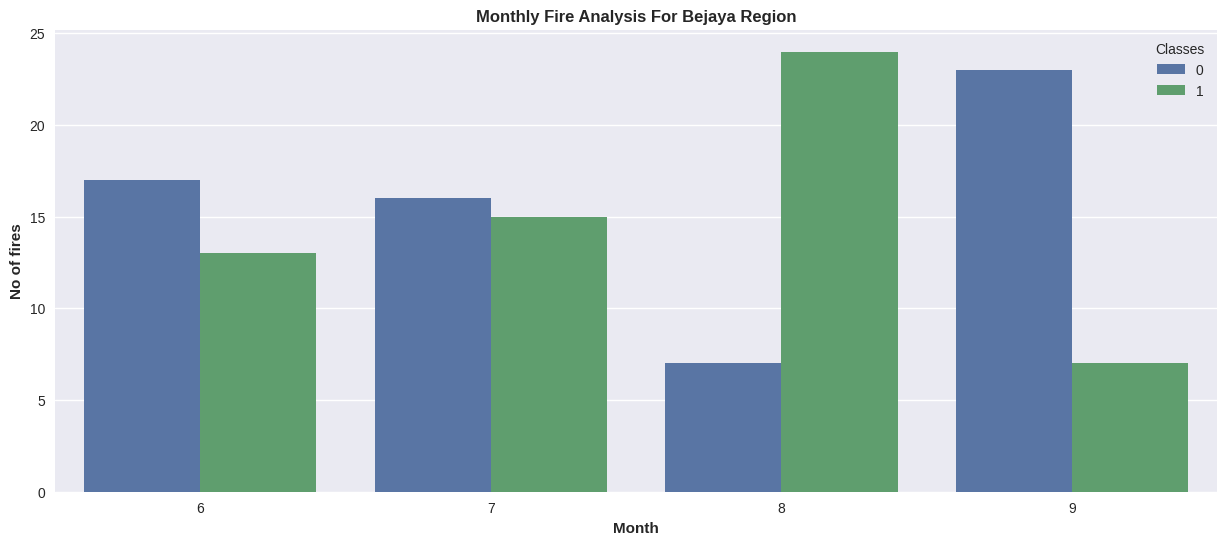

In [ ]:
#Monthly fire analysis-
dftemp = df.loc[df['Region']==0,:]
plt.subplots(figsize=(15,6))

#Fires high in 8th month in Bejaya Region-
sns.countplot(x='month',hue='Classes',data=dftemp)

plt.ylabel('No of fires',weight='bold')
plt.xlabel('Month',weight='bold')
plt.title('Monthly Fire Analysis For Bejaya Region',weight='bold')

Text(0.5, 1.0, 'Monthly Fire Analysis For Siddi Bel Abbes Region')

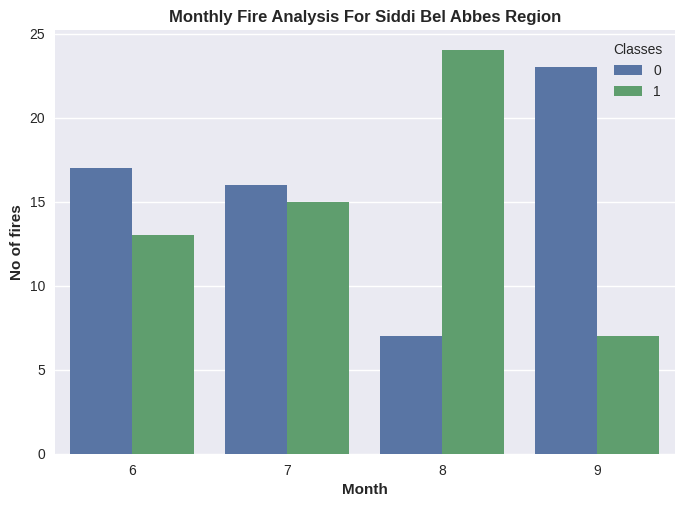

In [ ]:
#Siddi bel Abbes Region-
dftemp1 = df.loc[df['Region']==1,:]
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('No of fires',weight='bold')
plt.xlabel('Month',weight='bold')
plt.title('Monthly Fire Analysis For Siddi Bel Abbes Region',weight='bold')

IMP NOTE : BOTH BEJAYA AND SIDDI BEL-ABBES REGION HAD HIGHEST FIRES IN 8th MONTH OF THE YEAR (ie,August)

VERY HIGH FIRES OCCURED IN JUNE JULY AND AUGUST FOR BOTH THE REGIONS


#FEATURE SELECTION-

In [ ]:
df_ml = df_viz
#REGRESSION-dependent variable -- FWI
#CLASSIFICATION = dependent variable -- Classes

In [ ]:
#INDEPENDENT AND DEPENDENT FEATURES-
X= df_ml.drop('FWI',axis=1)
y= df_ml['FWI']


In [ ]:
#TRAIN TEST SPLIT-
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
X_train.shape

(182, 11)

In [ ]:
X_test.shape

(61, 11)

In [ ]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Figure size 1200x1000 with 0 Axes>

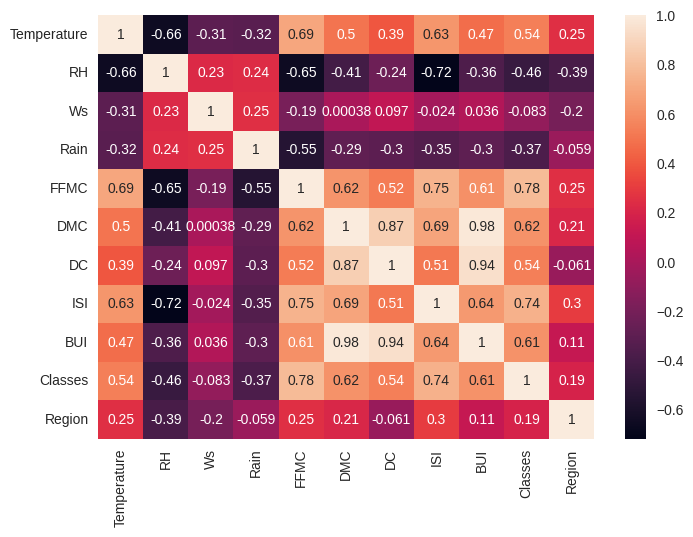

<Figure size 1200x1000 with 0 Axes>

In [ ]:
#CHECK FOR MULTICOLLINEATIY-
sns.heatmap(X_train.corr(),annot=True)
plt.figure(figsize=(12,10))


In [ ]:
#Function for checking multicollinearity(function able to handle +ve and negative corr)-
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [ ]:
#threshold - setup by domain expertise
corr_features= correlation(X_train,0.85)

In [ ]:
## DROP FEATURES WHEN CORRELATION>=0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [ ]:
X_train.shape

(182, 9)

In [ ]:
X_test.shape

(61, 9)

#STANDARDIZATION


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) #avoid data leakage.

#BOXPLOTS TO UNDERSTAND EFFECT OF STANDARD SCALER

Text(0.5, 1.0, 'X_train After Scaling')

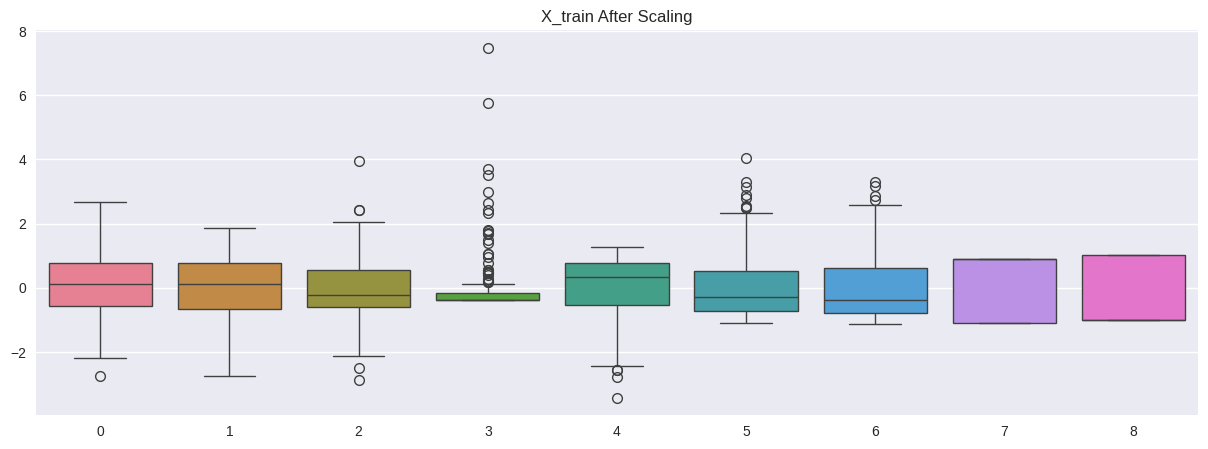

In [ ]:
#ALL THE INDEPENDENT FEATURES ARE IN SAME SCALE-
plt.subplots(figsize=(15, 5))
sns.boxplot(data=X_train)
plt.title('X_train After Scaling')

# MODEL TRAINING-

In [ ]:
#LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()
linreg.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=linreg.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred)

0.6742766873791607

In [ ]:
r2_score(y_test,y_pred)
#OVERFITTING

0.9847657384266951

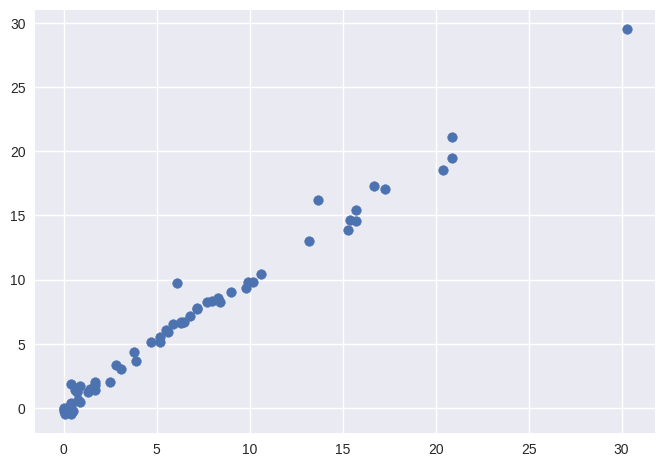

In [ ]:
plt.scatter(y_test,y_pred)

In [ ]:
#LASSO REGRESSION-
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train,y_train)


Lasso()

In [ ]:
y_pred=lasso.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.9492020263112388

In [ ]:
mean_squared_error(y_test,y_pred)

2.2483458918974772

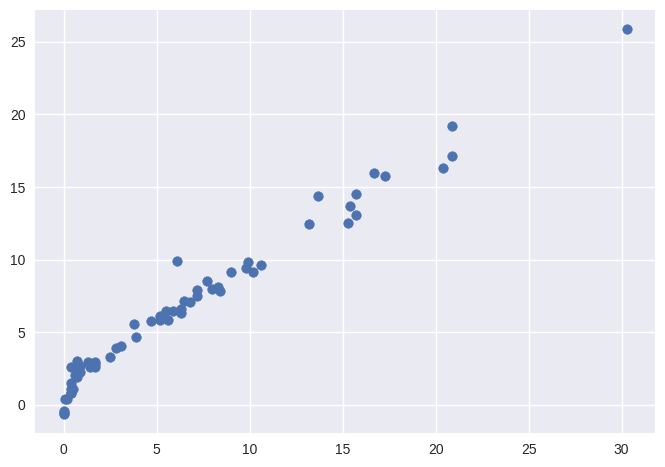

In [ ]:
plt.scatter(y_test,y_pred)

In [ ]:
#RIDGE REGRESSION-
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train,y_train)

Ridge()

In [ ]:
y_pred=ridge.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.9842993364555513

In [ ]:
mean_squared_error(y_test,y_pred)

0.6949198918152074

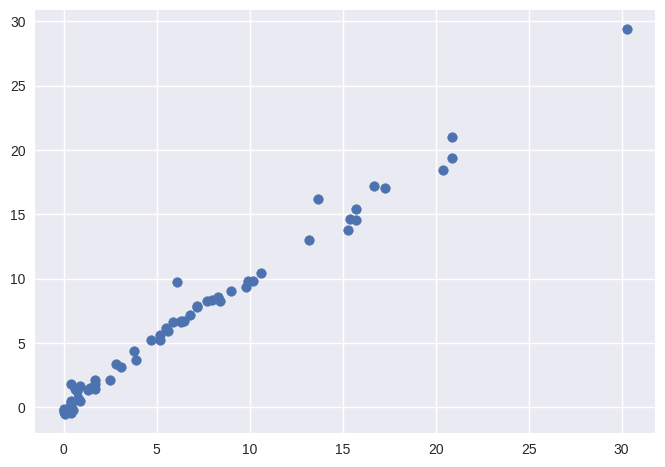

In [ ]:
plt.scatter(y_test,y_pred)

In [ ]:
#ELASTIC NET-
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(X_train,y_train)

ElasticNet()

In [ ]:
y_pred = elastic.predict(X_test)


In [ ]:
mean_squared_error(y_test,y_pred)

5.5172511010252245

In [ ]:
r2_score(y_test,y_pred)

0.8753460589519703

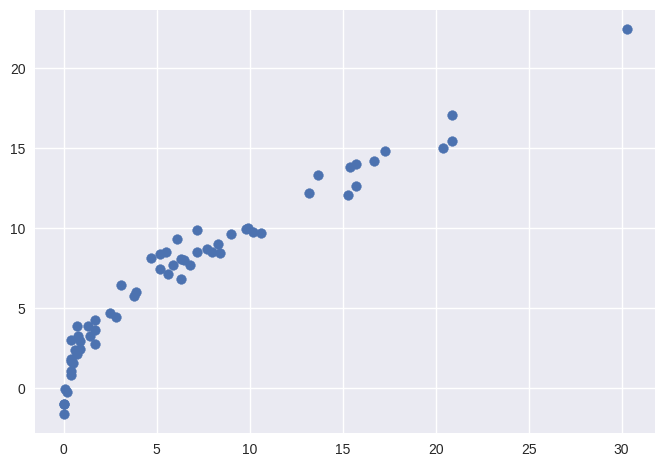

In [ ]:
plt.scatter(y_test,y_pred)

#HYPERPARAMETER TUNING-
cross validation using lassocv,ridgecv and elasticnetcv.

In [ ]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
#KFold Cross Validation-deafault k=5

In [ ]:
lassocv.fit(X_train,y_train)

LassoCV(cv=5)

In [ ]:
lassocv.predict(X_test)

array([ 8.17490595,  7.68312478, -0.25676525,  4.72643402,  6.78715772,
        1.77624325,  2.23148094,  7.64057821,  1.99176323,  3.39941035,
        0.62808928,  9.95945488,  9.36168319, 16.98503659, 18.28488762,
        1.61644108,  1.62751276, -0.6415713 ,  7.28510526,  3.10926518,
        1.95541903,  0.18069335,  6.47563129,  0.14318503, 20.99597009,
        5.11755206,  5.86208849,  9.75914403, -0.77037467,  9.91838577,
        6.72277075, -0.31776007, 10.31109643, 14.4365551 ,  1.71022677,
        0.83439752,  2.03414915,  5.97488529, -0.6263644 , -0.56200288,
        6.47253729,  2.07971408,  8.46741557, -0.8464481 , 15.40443856,
        8.32941189,  8.48782486,  1.44030355, 13.02752812,  1.20911545,
       29.08623849,  5.49737681, 17.15937199, 19.28890096, 13.71102991,
       16.05355549,  0.99056448,  9.0873725 ,  3.84455993, 14.43991192,
        5.23034139])

In [ ]:
lassocv.alpha_
#Alpha/lambda value that got selected after doing 100 iterations.

np.float64(0.05725391318234408)

In [ ]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [ ]:
lassocv.mse_path_
#100 alpha iterations and cv=5
#for each alpha cv=1,cv=2,cv=4,cv=5 (500 values od mse)

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

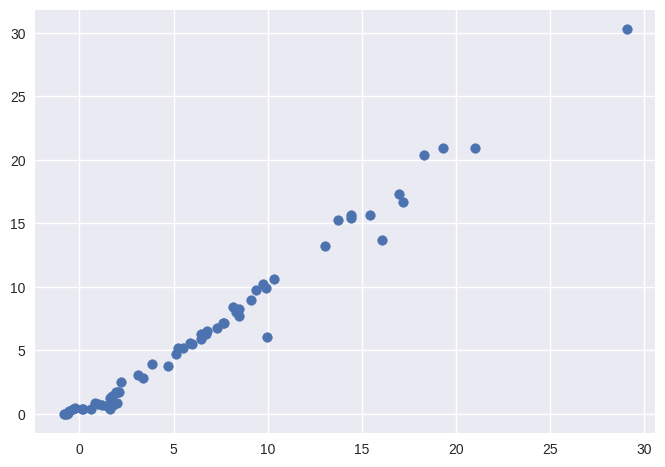

In [ ]:
y_pred = lassocv.predict(X_test)
plt.scatter(y_pred,y_test) #good linear relationship

In [ ]:
r2_score(y_test,y_pred)

0.9820946715928275

In [ ]:
mean_squared_error(y_test,y_pred)

0.792499555474362

In [ ]:
#Ridge Cross Validation-
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
#by default it uses leave one out cross validation.

ridgecv.fit(X_train,y_train)

RidgeCV(cv=5)

In [ ]:
y_pred = ridgecv.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.9842993364555513

In [ ]:
mean_squared_error(y_test,y_pred)

0.6949198918152074

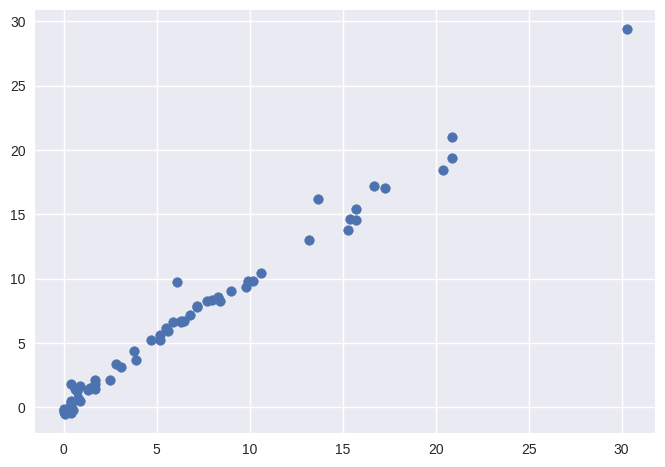

In [ ]:
plt.scatter(y_test,y_pred)

In [ ]:
ridgecv.alpha_

np.float64(1.0)

In [ ]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [ ]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

In [ ]:
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(cv=5)
elasticcv.fit(X_train,y_train)

ElasticNetCV(cv=5)

In [ ]:
#L1 ratio- focus on feature selection

In [ ]:
y_pred = elasticcv.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.9814217587854941

In [ ]:
mean_squared_error(y_test,y_pred)

0.8222830416276258

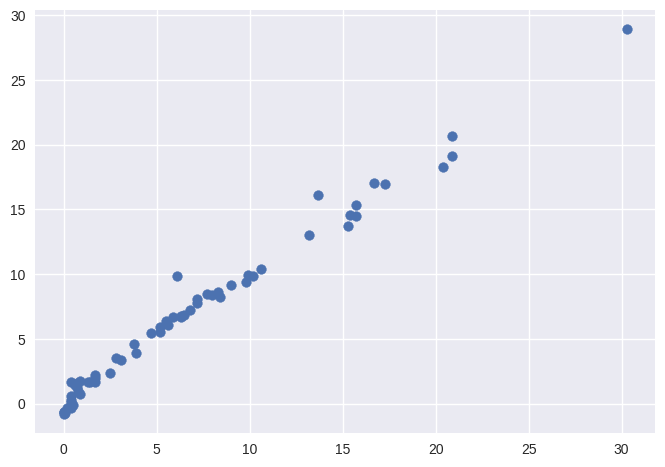

In [ ]:
plt.scatter(y_test,y_pred)

In [ ]:
elasticcv.alpha_

np.float64(0.04311146156383891)

In [ ]:
elasticcv.alphas_

array([14.11706004, 13.16561744, 12.27829889, 11.45078264, 10.67903821,
        9.95930678,  9.28808283,  8.66209714,  8.07830078,  7.53385034,
        7.02609405,  6.55255882,  6.11093829,  5.6990815 ,  5.31498248,
        4.95677045,  4.62270071,  4.31114616,  4.02058933,  3.74961507,
        3.49690356,  3.26122397,  3.04142839,  2.83644629,  2.64527931,
        2.46699633,  2.30072904,  2.1456676 ,  2.00105679,  1.86619226,
        1.74041714,  1.62311885,  1.51372607,  1.411706  ,  1.31656174,
        1.22782989,  1.14507826,  1.06790382,  0.99593068,  0.92880828,
        0.86620971,  0.80783008,  0.75338503,  0.7026094 ,  0.65525588,
        0.61109383,  0.56990815,  0.53149825,  0.49567705,  0.46227007,
        0.43111462,  0.40205893,  0.37496151,  0.34969036,  0.3261224 ,
        0.30414284,  0.28364463,  0.26452793,  0.24669963,  0.2300729 ,
        0.21456676,  0.20010568,  0.18661923,  0.17404171,  0.16231189,
        0.15137261,  0.1411706 ,  0.13165617,  0.12278299,  0.11